## Neural Sorting

This project explores the concept of sorting using neural networks.


## Loss function

The loss function compute the total entropy of a vector of numbers.
Entropy in this context must be interpreted as a measure of disorder, less the entropy, more ordered the vector is. The loss function is defined as follows:

`loss(x) = sum(|x_i - x_(i-1)|)
starting from i=1
`

Basically the loss function is the reduction sum of the absolute value of differences between each consecutive pair of elements in the vector.

## Loss validation (numerically)

A simple validation of the loss function can be done by computing the loss of a sorted vector and an unsorted vector `N` times, for `N` big enough we should think that the loss is correct. 

In [1]:
"""Unit Test for loss function"""

import numpy as np
from loss import disorder, disorder_test

SEED = 777
LENGTH_UPTO = 12
N = 1

disorder_test(N, LENGTH_UPTO, SEED)

## 3 Scenarios

### Scenario 1: Learn how to sort a specific permutation of the same vector
### Scenario 2: Learn how to sort a specific set of numbers
### Scenario 3: Learn how to generalize to arbitrary set of numbers

## Scenario 1: Learn how to sort a specific permutation of the same vector

The whole scenario consist in train the network to learn a specific permutation matrix that if applied to a specific vector, it will sort it. 

In [2]:
"""Model architecture"""

from thorcino.optimizer import SGD
from thorcino.training import CosineSchedule, Trainer
from thorcino.layers import Sequential, Linear
from loss import DisorderLoss, DisorderV2Loss

EPOCHS, EVAL_STEP = 50, 10
VECT_LENGTH = 5
MAX_LR, MIN_LR = 1e-3, 1e-6

model = Sequential(
    Linear(VECT_LENGTH, VECT_LENGTH)
)
loss = DisorderV2Loss()
optimizer = SGD(model.parameters, MAX_LR)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(
    model,
    loss,
    optimizer,
    scheduler
)

In [3]:
import numpy as np
from thorcino.tensor import Tensor

rng = np.random.default_rng(SEED)

input = rng.standard_normal(VECT_LENGTH)
target = np.sort(input)
input, target = Tensor(input), Tensor(target)

tr_loss_history = []
for i in range(EPOCHS):
    pred = model(input)
    tr_loss = loss(pred, target)
    tr_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    optimizer.lr = scheduler.get_lr(i)

    tr_loss_history.append(tr_loss.data)


print(f"predictions={pred.data}")
print(f"target={target.data}")
print(f"disorder pred={disorder(pred)}")
print(f"disorder target={disorder(target)}")
print(f"last loss={tr_loss_history[-1]}")

ValueError: backward() requires gradient for non-scalar

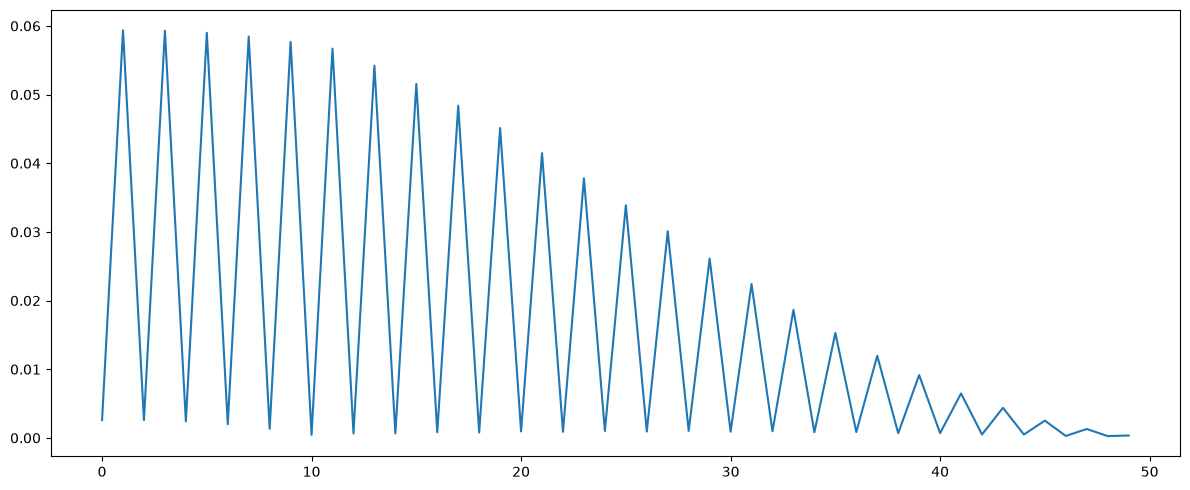

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), tr_loss_history)

fig.tight_layout()
plt.show()

## TODO:
Try with the same loss function but without sum reduction, the problem is the not-unicity of loss value.